In [1]:
import os
import pandas as pd
import re, string, nltk
from datasets import load_dataset
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
from nltk import word_tokenize, pos_tag
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD
import time

c:\Users\ysnxlmted\Projects\documents_classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Создание папки для nltk данных, если её нет
nltk_data_dir = os.path.expanduser('../nltk_data')
if not os.path.exists(nltk_data_dir):
    os.makedirs(nltk_data_dir)

# Добавление пути в nltk
nltk.data.path.append(nltk_data_dir)

# Загрузка всех необходимых ресурсов
resources = ['punkt', 'wordnet', 'omw-1.4', 'punkt_tab', 
             'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng', 'stopwords']

for resource in resources:
    try:
        nltk.download(resource, download_dir=nltk_data_dir, quiet=False)
    except:
        print(f"Ресурс {resource} уже загружен или произошла ошибка")

[nltk_data] Downloading package punkt to ../nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to ../nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to ../nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to ../nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ../nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     ../nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to ../nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[{}[\]()<>]', '', text)
    text = re.sub(r'\d+\.\d+\.\d+\.\d+', '', text)
    email_pattern = r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'
    text = re.sub(email_pattern, '', text)
    text = re.sub(r'\S+/\S+/\S+', '', text)
    text = re.sub(r'\S+\.\S+/\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[`"\']{2,}', ' ', text)
    text = re.sub(r'[`"\']', ' ', text)
    text = re.sub(r'[\[\]{}()<>]', ' ', text)
    text = re.sub(r'(\w+)-(\d+)', r'\1\2', text)
    text = re.sub(r'(\d+)-(\w+)', r'\1\2', text)
    smile_pattern = r'[:;=][\-^]?[)D\(\[\]pP]+'
    text = re.sub(smile_pattern, '', text)
    text = re.sub(r'([!?.,])\1+', r'\1', text)
    text = re.sub(r'-{2,}', ' ', text)
    text = re.sub(r'\+?\d[\d\s\-\(\)]{7,}\d', '', text)
    text = re.sub(r'[^\w\s]', ' ', text) 
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text

stop_words = set(stopwords.words("english"))
additional_stops = {
    'would', 'could', 'should', 'might', 'may', 'get', 'go', 'see', 
    'know', 'like', 'want', 'need', 'say', 'think', 'come', 'take',
    'use', 'make', 'well', 'also', 'even', 'many', 'much', 'still',
    'however', 'though', 'although', 'since', 'yet', 'already'
}
stop_words.update(additional_stops)

def get_wordnet_pos(tag):
    if tag.startswith('J'): return wordnet.ADJ
    elif tag.startswith('V'): return wordnet.VERB
    elif tag.startswith('R'): return wordnet.ADV
    else: return wordnet.NOUN

lemmatizer = nltk.WordNetLemmatizer()

def preprocess_with_lemmatization(text, pos_filter="all"):
    tokens = word_tokenize(clean_text(text))
    tagged = pos_tag(tokens)
    lemmatized_tokens = []
    for token, tag in tagged:
        if token in stop_words or token in string.punctuation:
            continue
        is_noun_adj = tag.startswith('N') or tag.startswith('J')
        if pos_filter == "nouns_adj" and not is_noun_adj:
            continue
        lemmatized_tokens.append(lemmatizer.lemmatize(token, get_wordnet_pos(tag)))
    return " ".join(lemmatized_tokens)

stemmer = PorterStemmer()
def preprocess_with_stemming(text):
    tokens = word_tokenize(clean_text(text))
    res = []
    for token in tokens:
        if token in stop_words or token in string.punctuation: continue
        res.append(stemmer.stem(token))
    return " ".join(res)

DS: 20 Newsgroups (4 selected)

In [4]:
from datasets import load_dataset
import pandas as pd

# 1. Загрузка
dataset = load_dataset("SetFit/20_newsgroups")
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

# 2. Полный список категорий (порядок фиксирован для 20 newsgroups)
all_categories = [
    'alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 
    'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 
    'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 
    'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 
    'sci.space', 'soc.religion.christian', 'talk.politics.guns', 
    'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc'
]

# 3. Выбираем нужные 4 категории
selected_categories = [    
    "comp.sys.ibm.pc.hardware",
    "comp.sys.mac.hardware", 
    "comp.graphics",
    "comp.windows.x"]

# 4. Находим их ID (индексы в общем списке)
selected_ids = [all_categories.index(cat) for cat in selected_categories]

# 5. Фильтрация по ID
train_df = train_df[train_df['label'].isin(selected_ids)].reset_index(drop=True)
test_df = test_df[test_df['label'].isin(selected_ids)].reset_index(drop=True)

# 6. Перемаппинг лейблов в 0, 1, 2, 3
label_map = {old_id: new_id for new_id, old_id in enumerate(selected_ids)}
train_df['label'] = train_df['label'].map(label_map)
test_df['label'] = test_df['label'].map(label_map)

print(f"✅ Классы: {selected_categories}")
print(f"📊 Train: {len(train_df)}, Test: {len(test_df)}")

Repo card metadata block was not found. Setting CardData to empty.


✅ Классы: ['comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.graphics', 'comp.windows.x']
📊 Train: 2345, Test: 1561


предобработка

In [5]:
print('Предобработка...')
train_df['text_simple'] = train_df['text'].apply(lambda x: preprocess_with_lemmatization(x, 'all'))
print('preprocess_with_lemmatization (all): END')
train_df['text_pos'] = train_df['text'].apply(lambda x: preprocess_with_lemmatization(x, 'nouns_adj'))
print('preprocess_with_lemmatization (nouns+adj): END')
train_df['text_stem'] = train_df['text'].apply(preprocess_with_stemming)
print('preprocess_with_stemming: END')

print('train preprocessing: END')

test_df['text_simple'] = test_df['text'].apply(lambda x: preprocess_with_lemmatization(x, 'all'))
print('preprocess_with_lemmatization (all): END')
test_df['text_pos'] = test_df['text'].apply(lambda x: preprocess_with_lemmatization(x, 'nouns_adj'))
print('preprocess_with_lemmatization (nouns+adj): END')
test_df['text_stem'] = test_df['text'].apply(preprocess_with_stemming)
print('preprocess_with_stemming: END')

print("✅ Предобработка завершена")

Предобработка...
preprocess_with_lemmatization (all): END
preprocess_with_lemmatization (nouns+adj): END
preprocess_with_stemming: END
train preprocessing: END
preprocess_with_lemmatization (all): END
preprocess_with_lemmatization (nouns+adj): END
preprocess_with_stemming: END
✅ Предобработка завершена


модели

In [6]:
from sklearn.model_selection import cross_val_score, cross_validate, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

# Параметры для кросс-валидации
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'f1_macro': 'f1_macro',
    'f1_micro': 'f1_micro'
}

# Слова для обработки
preprocessing_methods = {
    'Lemmatization (all)': 'text_simple',
    'Lemmatization (nouns+adj)': 'text_pos',
    'Stemming': 'text_stem'
}

# Словарь для всех результатов
all_results = {}

print("="*80)
print("ОБУЧЕНИЕ НА ТРЕХ ВАРИАНТАХ ПРЕДОБРАБОТКИ")
print("="*80)

ОБУЧЕНИЕ НА ТРЕХ ВАРИАНТАХ ПРЕДОБРАБОТКИ


In [13]:
# Модели
models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
}

# Цикл по всем методам предобработки
for prep_name, text_column in preprocessing_methods.items():
    print("\n" + "="*80)
    print(f"📋 МЕТОД ПРЕДОБРАБОТКИ: {prep_name}")
    print("="*80 + "\n")
    
    # TF-IDF векторизация
    print(f"🔄 Векторизация текстов ({prep_name})...")
    vectorizer = TfidfVectorizer(
        min_df=2,
        max_df=0.8,
        ngram_range=(1, 2),
        stop_words='english'
    )
    
    X_train = vectorizer.fit_transform(train_df[text_column])
    y_train = train_df['label'].values
    
    X_test = vectorizer.transform(test_df[text_column])
    y_test = test_df['label'].values
    
    print(f"✅ X_train: {X_train.shape}, X_test: {X_test.shape}")
    print(f"📊 Количество векторизованных признаков: {X_train.shape[1]}\n")
    
    # Кросс-валидация
    print("РЕЗУЛЬТАТЫ КРОСС-ВАЛИДАЦИИ (5-fold StratifiedKFold)")
    print("-"*80)
    
    cv_results_prep = {}
    
    for model_name, model in models.items():
        # Кросс-валидация
        scores = cross_validate(
            model, X_train, y_train,
            cv=cv,
            scoring=scoring,
            return_train_score=True,
            n_jobs=-1
        )
        
        cv_results_prep[model_name] = scores
        
        # Вывод результатов по каждой метрике
        print(f"\n📊 {model_name}")
        for metric in ['f1_macro', 'f1_micro']:
            test_scores = scores[f'test_{metric}']
            train_scores = scores[f'train_{metric}']
            
            print(f"  {metric.upper():15s} | "
                  f"Test: {test_scores.mean():.4f} ± {test_scores.std():.4f} | "
                  f"Train: {train_scores.mean():.4f} ± {train_scores.std():.4f}")
    
    # Финальное тестирование
    print("\n" + "-"*80)
    print("ТЕСТИРОВАНИЕ НА ТЕСТОВОМ СЕТЕ")
    print("-"*80)
    
    test_results_prep = {}
    
    for model_name, model in models.items():
        # Обучение
        model.fit(X_train, y_train)
        
        # Предсказание на тестовом сете
        y_pred = model.predict(X_test)
        
        # Метрики на тестовом сете
        test_f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
        test_f1_micro = f1_score(y_test, y_pred, average='micro', zero_division=0)
        
        test_results_prep[model_name] = {
            'f1_macro': test_f1_macro,
            'f1_micro': test_f1_micro
        }
        
        print(f"\n📊 {model_name}")
        print(f"  F1-Score (Macro): {test_f1_macro:.4f}")
        print(f"  F1-Score (Micro): {test_f1_micro:.4f}")
    
    # Сохранение результатов
    all_results[prep_name] = {
        'cv': cv_results_prep,
        'test': test_results_prep,
        'vectorizer': vectorizer
    }

print("\n" + "="*80)
print("✅ ОБУЧЕНИЕ ЗАВЕРШЕНО НА ВСЕ МЕТОДАХ ПРЕДОБРАБОТКИ")
print("="*80)


📋 МЕТОД ПРЕДОБРАБОТКИ: Lemmatization (all)

🔄 Векторизация текстов (Lemmatization (all))...
✅ X_train: (2345, 27395), X_test: (1561, 27395)
📊 Количество векторизованных признаков: 27395

РЕЗУЛЬТАТЫ КРОСС-ВАЛИДАЦИИ (5-fold StratifiedKFold)
--------------------------------------------------------------------------------

📊 Decision Tree
  F1_MACRO        | Test: 0.5636 ± 0.0142 | Train: 0.6741 ± 0.0106
  F1_MICRO        | Test: 0.5527 ± 0.0141 | Train: 0.6611 ± 0.0098

📊 Random Forest
  F1_MACRO        | Test: 0.7622 ± 0.0146 | Train: 0.8596 ± 0.0032
  F1_MICRO        | Test: 0.7599 ± 0.0152 | Train: 0.8572 ± 0.0029

--------------------------------------------------------------------------------
ТЕСТИРОВАНИЕ НА ТЕСТОВОМ СЕТЕ
--------------------------------------------------------------------------------

📊 Decision Tree
  F1-Score (Macro): 0.5347
  F1-Score (Micro): 0.5259

📊 Random Forest
  F1-Score (Macro): 0.7336
  F1-Score (Micro): 0.7316

📋 МЕТОД ПРЕДОБРАБОТКИ: Lemmatization (nou


СРАВНИТЕЛЬНАЯ ТАБЛИЦА: F1-Score на тестовом сете
            Preprocessing         Model  F1-Macro  F1-Micro
      Lemmatization (all) Decision Tree  0.534705  0.525945
      Lemmatization (all) Random Forest  0.733597  0.731582
Lemmatization (nouns+adj) Decision Tree  0.527749  0.519539
Lemmatization (nouns+adj) Random Forest  0.721473  0.718129
                 Stemming Decision Tree  0.558176  0.546445
                 Stemming Random Forest  0.745090  0.743113


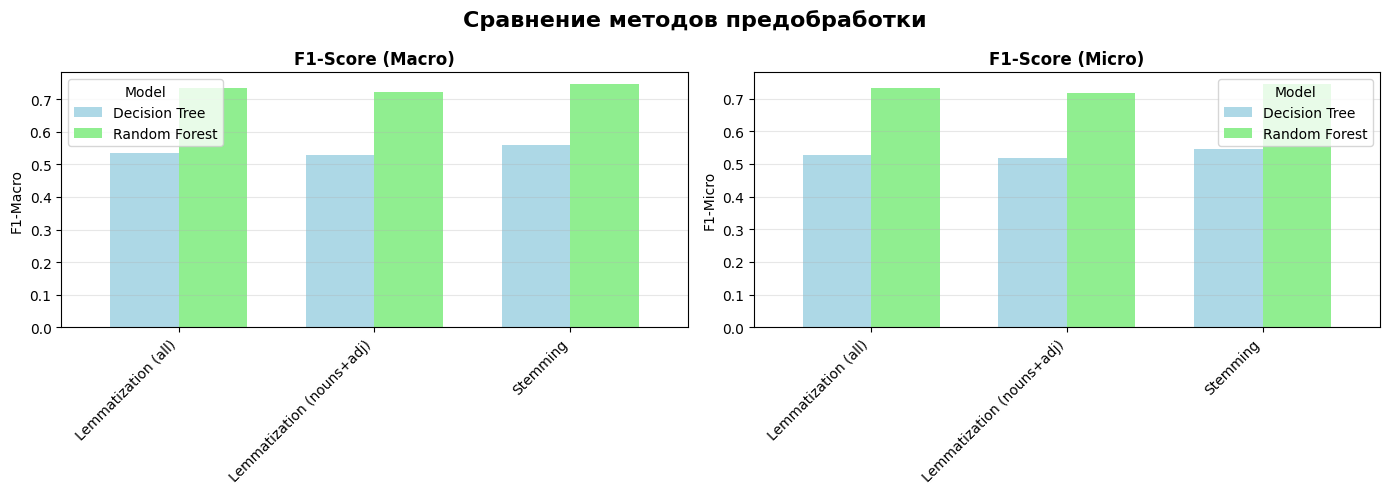


ЛУЧШИЕ РЕЗУЛЬТАТЫ

🏆 Best F1-Macro:
   Preprocessing: Stemming
   Model: Random Forest
   F1-Macro: 0.7451

🏆 Best F1-Micro:
   Preprocessing: Stemming
   Model: Random Forest
   F1-Micro: 0.7431

✅ Анализ завершен!


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# СРАВНИТЕЛЬНАЯ ТАБЛИЦА ВСЕХ МЕТОДОВ
# ============================================

print("\n" + "="*80)
print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА: F1-Score на тестовом сете")
print("="*80)

comparison_data = []

for prep_name in preprocessing_methods.keys():
    for model_name in models.keys():
        f1_macro = all_results[prep_name]['test'][model_name]['f1_macro']
        f1_micro = all_results[prep_name]['test'][model_name]['f1_micro']
        
        comparison_data.append({
            'Preprocessing': prep_name,
            'Model': model_name,
            'F1-Macro': f1_macro,
            'F1-Micro': f1_micro
        })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Сравнение методов предобработки', fontsize=16, fontweight='bold')

# F1-Macro
pivot_macro = comparison_df.pivot(index='Preprocessing', columns='Model', values='F1-Macro')
pivot_macro.plot(kind='bar', ax=axes[0], color=['lightblue', 'lightgreen'], width=0.7)
axes[0].set_title('F1-Score (Macro)', fontweight='bold')
axes[0].set_ylabel('F1-Macro')
axes[0].set_xlabel('')
axes[0].legend(title='Model')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# F1-Micro
pivot_micro = comparison_df.pivot(index='Preprocessing', columns='Model', values='F1-Micro')
pivot_micro.plot(kind='bar', ax=axes[1], color=['lightblue', 'lightgreen'], width=0.7)
axes[1].set_title('F1-Score (Micro)', fontweight='bold')
axes[1].set_ylabel('F1-Micro')
axes[1].set_xlabel('')
axes[1].legend(title='Model')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Лучший результат
print("\n" + "="*80)
print("ЛУЧШИЕ РЕЗУЛЬТАТЫ")
print("="*80)
best_macro = comparison_df.loc[comparison_df['F1-Macro'].idxmax()]
best_micro = comparison_df.loc[comparison_df['F1-Micro'].idxmax()]

print("\n🏆 Best F1-Macro:")
print(f"   Preprocessing: {best_macro['Preprocessing']}")
print(f"   Model: {best_macro['Model']}")
print(f"   F1-Macro: {best_macro['F1-Macro']:.4f}")

print("\n🏆 Best F1-Micro:")
print(f"   Preprocessing: {best_micro['Preprocessing']}")
print(f"   Model: {best_micro['Model']}")
print(f"   F1-Micro: {best_micro['F1-Micro']:.4f}")

print("\n✅ Анализ завершен!")

In [9]:
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder

In [10]:
# Словарь для перебора всех вариантов предобработки
preprocessing_methods = {
    'Lemmatization (all)': 'text_simple',
    'Lemmatization (nouns+adj)': 'text_pos',
    'Stemming': 'text_stem'
}

lstm_results = []

for prep_name, text_col in preprocessing_methods.items():
    print(f"\n{'='*80}")
    print(f"🚀 Обучение LSTM на: {prep_name}")
    print(f"{'='*80}")
    
    # 1. Очистка сессии и сбор мусора (важно для избежания утечек памяти при цикле)
    tf.keras.backend.clear_session()
    import gc; gc.collect()
    
    # 2. Токенизация и паддинг
    tokenizer = Tokenizer(num_words=10000)
    tokenizer.fit_on_texts(train_df[text_col])
    
    X_train = pad_sequences(tokenizer.texts_to_sequences(train_df[text_col]), maxlen=100)
    X_test  = pad_sequences(tokenizer.texts_to_sequences(test_df[text_col]),  maxlen=100)
    
    y_train = train_df['label'].values
    y_test  = test_df['label'].values
    
    # 3. Построение модели (архитектура из твоего PDF, адаптированная под 4 класса)
    model = Sequential([
        Embedding(len(tokenizer.word_index) + 1, 100, input_length=100),
        SpatialDropout1D(0.2),
        LSTM(100, dropout=0.2, recurrent_dropout=0.2),
        Dense(4, activation='softmax')
    ])
    
    model.compile(
        loss='sparse_categorical_crossentropy', 
        optimizer=Adam(learning_rate=0.01), 
        metrics=['accuracy']
    )
    
    # 4. Обучение
    model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.1, verbose=1)
    
    # 5. Предсказание и оценка
    y_pred_proba = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred_proba, axis=1)
    
    f1_macro = f1_score(y_test, y_pred_classes, average='macro', zero_division=0)
    f1_micro = f1_score(y_test, y_pred_classes, average='micro', zero_division=0)
    
    print(f"✅ F1-Macro: {f1_macro:.4f} | F1-Micro: {f1_micro:.4f}")
    
    lstm_results.append({
        'Preprocessing': prep_name,
        'Model': 'LSTM',
        'F1-Macro': f1_macro,
        'F1-Micro': f1_micro
    })

# ==========================================
# Итоговая таблица сравнения
# ==========================================
results_df = pd.DataFrame(lstm_results)

print("\n" + "="*80)
print("📊 СРАВНИТЕЛЬНАЯ ТАБЛИЦА: LSTM по видам предобработки")
print("="*80)
print(results_df.to_string(index=False))

# Найдем лучший вариант
best_lstm = results_df.loc[results_df['F1-Macro'].idxmax()]
print(f"\n🏆 Лучший LSTM: {best_lstm['Preprocessing']} | F1-Macro: {best_lstm['F1-Macro']:.4f}")


🚀 Обучение LSTM на: Lemmatization (all)



c:\Users\ysnxlmted\Projects\documents_classification\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 21s 367ms/step - accuracy: 0.4246 - loss: 1.1741 - val_accuracy: 0.5404 - val_loss: 0.9537
Epoch 2/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 348ms/step - accuracy: 0.7791 - loss: 0.5983 - val_accuracy: 0.6809 - val_loss: 0.9572
Epoch 3/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 344ms/step - accuracy: 0.9076 - loss: 0.2952 - val_accuracy: 0.6979 - val_loss: 0.9581
Epoch 4/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 376ms/step - accuracy: 0.9531 - loss: 0.1441 - val_accuracy: 0.7149 - val_loss: 0.9802
Epoch 5/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 301ms/step - accuracy: 0.9720 - loss: 0.0743 - val_accuracy: 0.7532 - val_loss: 1.1111
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step
✅ F1-Macro: 0.6788 | F1-Micro: 0.6803

🚀 Обучение LSTM на: Lemmatization (nouns+adj)
Epoch 1/5


c:\Users\ysnxlmted\Projects\documents_classification\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


33/33 ━━━━━━━━━━━━━━━━━━━━ 20s 375ms/step - accuracy: 0.4450 - loss: 1.2014 - val_accuracy: 0.5149 - val_loss: 1.1182
Epoch 2/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 14s 427ms/step - accuracy: 0.7839 - loss: 0.5633 - val_accuracy: 0.6979 - val_loss: 0.8883
Epoch 3/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 555ms/step - accuracy: 0.9175 - loss: 0.2333 - val_accuracy: 0.7319 - val_loss: 0.9929
Epoch 4/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 275ms/step - accuracy: 0.9630 - loss: 0.1083 - val_accuracy: 0.7021 - val_loss: 1.0592
Epoch 5/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 240ms/step - accuracy: 0.9773 - loss: 0.0609 - val_accuracy: 0.7277 - val_loss: 1.2253
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step
✅ F1-Macro: 0.6989 | F1-Micro: 0.7002

🚀 Обучение LSTM на: Stemming
Epoch 1/5


c:\Users\ysnxlmted\Projects\documents_classification\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 329ms/step - accuracy: 0.4261 - loss: 1.2012 - val_accuracy: 0.5574 - val_loss: 1.0162
Epoch 2/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 258ms/step - accuracy: 0.7730 - loss: 0.6186 - val_accuracy: 0.6468 - val_loss: 0.8770
Epoch 3/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 270ms/step - accuracy: 0.8867 - loss: 0.3181 - val_accuracy: 0.6979 - val_loss: 1.0181
Epoch 4/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 292ms/step - accuracy: 0.9455 - loss: 0.1481 - val_accuracy: 0.6936 - val_loss: 0.9698
Epoch 5/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 253ms/step - accuracy: 0.9682 - loss: 0.0919 - val_accuracy: 0.7191 - val_loss: 1.1785
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step
✅ F1-Macro: 0.6591 | F1-Micro: 0.6573

📊 СРАВНИТЕЛЬНАЯ ТАБЛИЦА: LSTM по видам предобработки
            Preprocessing Model  F1-Macro  F1-Micro
      Lemmatization (all)  LSTM  0.678831  0.680333
Lemmatization (nouns+adj)  LSTM  0.698921  0.700192
                 Stemming  LSTM  0.659112  0.657271

🏆 Лучший LSTM: Lemmatization (no